In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
import json
import copy
import numpy as np
import statistics as stat

# Mainly for progress bars
from tqdm import tqdm as tqdm


from community_system_mapping import COMMUNITY_TO_SYSTEM, NON_SYMPTOMS

In [2]:
# First load the graph since we will be using it for the research questions
G = nx.read_graphml("./NetworkFiles/network_graph_symptom.graphml")
print("Network loaded!")

Network loaded!


In [ ]:
#-----------------------------------------------------------------------------------------------------#
# Could we determine which system of the body requires attention based solely on the symptoms present?
#-----------------------------------------------------------------------------------------------------#

In [3]:
# This is the Louvain method.
# Using this as reference:
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html
# Lucky number 24
def detect_body_systems(seed=24):
    # Detect communities using NetworkX's Louvain implementation
    communities = nx.community.louvain_communities(G, seed=seed)

    # This is just enumerating the communities.
    # For each community, we make the node the key and the community value, the value
    community_dict = {}
    for community, community_nodes in enumerate(communities):
        for node in community_nodes:
            community_dict[node] = community

    communities_df = pd.DataFrame({
        "node": list(community_dict.keys()),
        "communities": list(community_dict.values())
    })

    return community_dict, communities_df


In [4]:
# Function to export the graph with communitites. WIll use this for visualization later...
def export_graph_with_communities(graph, community_dict):

    G_output = graph.copy()

    for non_symptom in NON_SYMPTOMS:
        if non_symptom in G_output:
            G_output.remove_node(non_symptom)

    # Only labeling body systems for our meaningful communities...
    for node in G_output.nodes():
        if node in community_dict:
            G_output.nodes[node]["community"] = community_dict[node]

            if community_dict[node] in COMMUNITY_TO_SYSTEM:
                G_output.nodes[node]["body_system"] = COMMUNITY_TO_SYSTEM[community_dict[node]]


    # Then just export it to GRAPHML
    nx.write_graphml(G_output, "./NetworkFiles/community_graph_symptom.graphml")
    print("Finished writing new community graph ml!")


In [38]:
def export_graph_only_communities(graph, community_dict):
    G_output = graph.copy()

    for non_symptom in NON_SYMPTOMS:
        if non_symptom in G_output:
            G_output.remove_node(non_symptom)

    for node in G_output.nodes():
        if node in community_dict:
            original_community = community_dict[node]
            G_output.nodes[node]["original_community"] = original_community

            if original_community in COMMUNITY_TO_SYSTEM:
                G_output.nodes[node]["body_system"] = COMMUNITY_TO_SYSTEM[original_community]

    # Only keeping nodes with our meaningful communities
    nodes_to_keep = []
    for node in G_output.nodes():
        if "body_system" in G_output.nodes[node]:
            nodes_to_keep.append(node)

    G_meaningful_comms = G_output.subgraph(nodes_to_keep).copy()

    for node in G_meaningful_comms.nodes():
        original_community = G_meaningful_comms.nodes[node]["original_community"]
        G_meaningful_comms.nodes[node]["community"] = original_community

    # Then just export it to GRAPHML
    nx.write_graphml(G_meaningful_comms, "./NetworkFiles/community_graph_only_symptom.graphml")
    print("Finished writing new community graph ml! ONLY MAIN COMMUNITIES")

In [6]:
def calc_member_strength(G, community_dict):

    # Now, we make a list to handle each object
    node_member_strength = []

    # Now we go through EACH node
    for node in G.nodes():
        community_number = community_dict[node]
        internal_connections = 0
        external_connections = 0

        # And for each symptom, we check their neighbour.
        for neighbour in G.neighbors(node):
            edge_weight = G[node][neighbour]['weight']

            # We now check if that neighbour is in the same community.
            if community_number == community_dict[neighbour]:
                internal_connections += edge_weight

            # Otherwise,
            else:
                external_connections += edge_weight

        total_weight = internal_connections + external_connections
        # Now we calculate the ratio
        # But make sure we don't divide by 0
        if total_weight > 0:
            member_strength = internal_connections / total_weight
        else:
            member_strength = 0

        node_member_strength.append({
            "symptom": node,
            "community": community_number,
            "member_strength": member_strength,
            "internal_connections": internal_connections,
            "external_connections": external_connections,
            "total_weight": total_weight
        })

    # Easily convert to df (since its easier to use seaborn and visualizations)
    member_strength_df = pd.DataFrame(node_member_strength)

    return member_strength_df

In [7]:
def system_identification(community_dict, member_strength_df):

    community_df = pd.DataFrame({
        "symptom": list(community_dict.keys()),
        "community": list(community_dict.values())
    })

    # We then count nodes in each community, finding the largest one.
    community_sizes = community_df["community"].value_counts()

    # Now we want to get the top communities, let's say 10 for now?
    top_communities_by_size = community_sizes.nlargest(10)

    print(top_communities_by_size)

    # Now, we can get the top symptoms of those top communities.
    # We calculated the membership strength earlier
    meaningful_communities = {}

    for community_number in top_communities_by_size.index:
        symptoms_of_community = member_strength_df[member_strength_df["community"] == community_number]

        # Only going to get the top symptoms
        # For one of the communitites, there are like 1400 symptoms
        top_symptoms = symptoms_of_community.nlargest(10, "member_strength")

        meaningful_communities[community_number] = {
            "top_symptoms": top_symptoms["symptom"].to_list(),
            "size": top_communities_by_size[community_number]
        }

    return community_df, meaningful_communities


In [32]:
def create_body_system_visualizations(community_dict):

    # First, we filter to include only symptoms in meaningful communities
    meaningful_comms = set(COMMUNITY_TO_SYSTEM.keys())
    filtered_symptoms = {}
    for symptom, community in community_dict.items():
        if community in meaningful_comms:
            filtered_symptoms[symptom] = community

    # Then we make the dataframe for seaborn...
    research_1_df = pd.DataFrame({
        "symptom": list(filtered_symptoms.keys()),
        "community": list(filtered_symptoms.values())
    })

    # Then we map each community number to
    research_1_df["body_system"] = research_1_df["community"].map(COMMUNITY_TO_SYSTEM)

    # Then we count the symptoms of each body system
    system_counts = research_1_df["body_system"].value_counts()

    plt.figure(figsize=(12, 6))
    # Interesting thing in seaborn...
    # passing pallete without assigning hue is deprecated.
    # Need to set hue to y, while also disabling the legend to False
    ax = sns.barplot(
        y=system_counts.index,
        x=system_counts.values,
        hue=system_counts.index,
        palette='viridis',
        orient='h',
        legend=False
    )

    for i, v in enumerate(system_counts.values):
        ax.text(v + 5, i, f"{v}", va='center')

    plt.title('Distribution of Symptoms Across Body Systems', fontsize=16)
    plt.xlabel('Number of Symptoms', fontsize=12)
    plt.ylabel('Body System', fontsize=12)
    plt.tight_layout()
    plt.savefig('system_size_distribution.png', dpi=300, bbox_inches='tight')


In [35]:
community_dict, communities_df = detect_body_systems(seed=24)

# Addin this for my communities for visualization alter...HAD TO ADD THE SEED. I completely forgot they had a seed for reproducability...
# https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.louvain.louvain_communities.html
export_graph_with_communities(G.copy(), community_dict)

Finished writing new community graph ml!


In [34]:
export_graph_only_communities(G.copy(), community_dict)

Finished writing new community graph ml! ONLY MAIN COMMUNITIES


In [11]:
member_strength_df = calc_member_strength(G, community_dict)

In [14]:
# Checking the statistics using the describe() function of dataframes
membership_stats = member_strength_df["member_strength"].describe()
print(membership_stats)

Highest membership strength: 1.0
count    8595.000000
mean        0.677895
std         0.225490
min         0.000000
25%         0.500000
50%         0.666667
75%         0.857143
max         1.000000
Name: member_strength, dtype: float64


In [10]:
community_df, meaningful_communities = system_identification(community_dict, member_strength_df)

community
5     1741
6     1601
0     1112
1     1059
2     1035
8      924
4      618
48     289
40      15
58      11
Name: count, dtype: int64


In [45]:
# First want to extract top symptoms to see what that community is...
communities_to_analyze = [5, 6, 0, 1, 2, 8, 2, 4, 48, 40, 58]
community_symptoms = {}

for community_id in communities_to_analyze:
    community_df = member_strength_df[member_strength_df["community"] == community_id]

    # Will get 50 symptoms
    top_symptoms = community_df.nlargest(50, "member_strength")

    # Then we just store it in the dictionary
    community_symptoms[community_id] = top_symptoms["symptom"].tolist()

# Then just write to file for reference....
with open("top_community_symptoms.txt", "w") as file:
    for community_id, symptoms in community_symptoms.items():
        file.write(f"Community {community_id}: \n")
        file.write("-" * 30 + "\n")
        for symptom in symptoms:
            file.write(f"{symptom}\n")
        file.write("\n\n")

print("Saved top symptoms!")


Saved top symptoms!


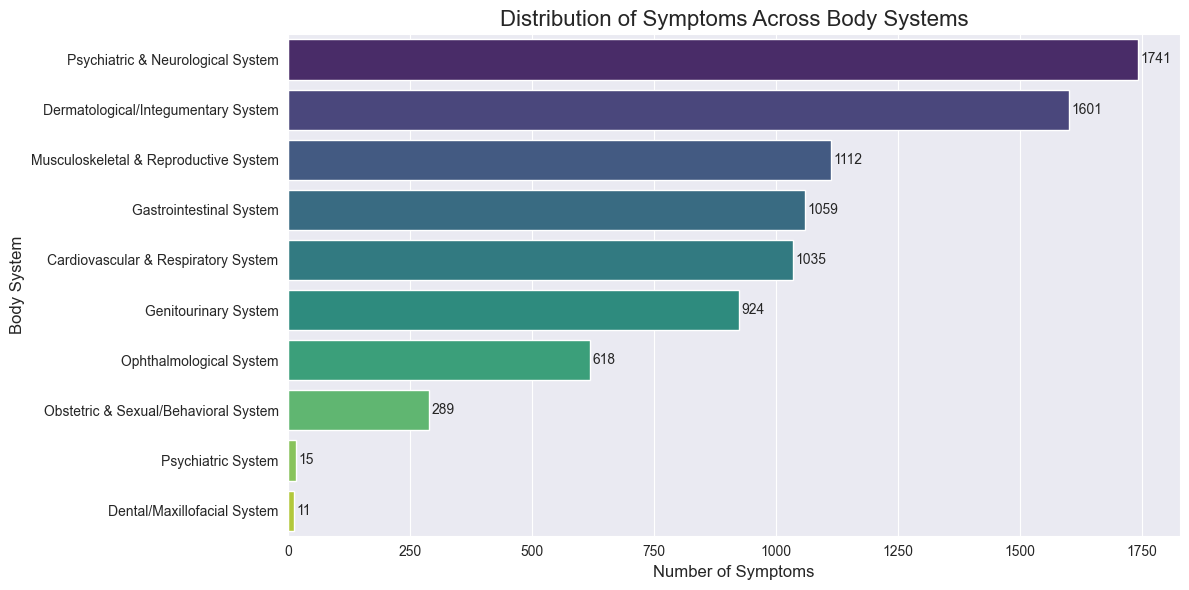

In [33]:
create_body_system_visualizations(community_dict)

In [ ]:
#----------------------------------------------------------------------------------------#
# Are there diseases that are more likely to be misdiagnosed due to their common symptoms?
#----------------------------------------------------------------------------------------#
# Also didn't really like making functions earlier, so I'll try not doing that.

In [15]:
# First we load the processed_dataset BECAUSE we need to see which symptoms belong to which disease.
# The graph alone, from the graphml file doesn't do this well.
try:
    with open("./DatabaseFiles/processed_dataset.json", "r") as file:
        disease_data = json.load(file)
except Exception as error:
    print(f"ERROR: {error}")

# Will only include the symptoms that actually exist in our network...
disease_symptoms = {}

# Using the processed_dataset (since its the dataset that was cleaned when building the network).
for entry in disease_data:
    disease = entry.get("disease", "").strip()
    # It is an array, so we don't need to strip or anything
    processed_symptoms = entry.get("processed_symptoms", [])

    # But we only get the symptoms that are in our network
    valid_symptoms = [symptom for symptom in processed_symptoms if symptom in G.nodes()]

    # Now if both disease and valid_symptoms aren't null...
    if disease and valid_symptoms:
        disease_symptoms[disease] = set(valid_symptoms)

print(f"There were {len(disease_symptoms)} with their symptoms.")

There were 8421 with their symptoms.


In [16]:
# Used this as a reference
# https://en.wikipedia.org/wiki/Jaccard_index
# You need two sets
# It is the intersection of A and B, divided by the union.
def calc_jaccard_similarity(A, B):
    # J(A, B) = |A ∩ B| / |A U B|
    # So we get the size of each one
    AB_intersection = len(set(A).intersection(set(B)))
    AB_union = len(set(A).union(set(B)))

    # To avoid division by 0 errors...
    if AB_union != 0:
        return AB_intersection / AB_union
    else:
        return 0

In [17]:
# Now we make a list of dictionaries for the jaccard similarity
# We can define a similarity threshold. Maybe make it 0.3 for now?
print("Calculating similarity between disease pairs with their symptoms")
all_diseases = list(disease_symptoms.keys())
disease_pairs = []
similarity_threshold = 0.3

# Will also use tqdm for the progress bar
num_diseases = len(all_diseases)
with tqdm(total=num_diseases, desc="Calculating node paths") as progress_bar:

    # This is going to be of n^2 complexity.
    # Not much to optimize though since we need see each pair
    for index1 in range(num_diseases):
        for index2 in range(index1 + 1, num_diseases):
            first_disease = all_diseases[index1]
            second_disease = all_diseases[index2]

            # If the diseases are the same, just skip
            # Don't need to compare similarity with itself
            if first_disease == second_disease:
                continue

            first_symptoms = disease_symptoms[first_disease]
            second_symptoms = disease_symptoms[second_disease]

            # Now we calculate the jaccard similarity
            similarity = calc_jaccard_similarity(first_symptoms, second_symptoms)

            # Checking if the similarity
            if similarity >= similarity_threshold:
                # Now we can get the common symptoms (the intersection between the two).
                common_symptoms = first_symptoms.intersection(second_symptoms)

                # Also, we can easily see which symptoms are unique to the disease
                # This is just by subtracting the two sets.
                # Just basic set theory
                first_unique_symptoms = first_symptoms - second_symptoms
                second_unique_symptoms = second_symptoms - first_symptoms

                # Now, we can add the dictionary to the list
                disease_pair = {
                    "first_disease": first_disease,
                    "second_disease": second_disease,
                    "similarity": similarity,
                    "common_symptoms": list(common_symptoms),
                    "first_unique_symptoms": list(first_unique_symptoms),
                    "second_unique_symptoms": list(second_unique_symptoms),
                }

                disease_pairs.append(disease_pair)

        progress_bar.update(1)

print(f"There were {len(disease_pairs)} disease pairs that were made. Similarity threshold = {similarity_threshold}")

Calculating similarity between disease pairs with their symptoms


Calculating node paths: 100%|██████████| 8421/8421 [01:16<00:00, 110.17it/s] 

There were 53656 disease pairs that were made. Similarity threshold = 0.3


In [18]:
disease_pairs2 = disease_pairs.copy()
len(disease_pairs2)

53656

In [19]:
# Technically don't need this, but it makes it easier to load the data later if I need to.
# But I would have to use Louvain again
def load_communities(path: None):

    if path:
        try:
            with open(path, "r") as community_file:
                node_communities = json.load(community_file)
            return node_communities
        except Exception as error:
            print(f"ERROR: {error}")

    # Otherwise, we didn't specify a path so just use Louvain
    else:
        print("No path provided so will detect communities with Louvain method...")
        communities_louvain = nx.community.louvain_communities(G, seed=24)

        # Then just create the mapping for their numbers, similar to what we did for research question 1
        # They won't be the same I think because it is another iteration of this method
        # Won't be the same from research question 1
        node_communities = {}
        for community_number, community in enumerate(communities_louvain):
            for node in community:
                node_communities[node] = community_number

        return node_communities

In [20]:
node_communities = load_communities(None)
print(len(node_communities))

No path provided so will detect communities with Louvain method...
8595


In [21]:
print(len(set(node_communities.values())))

86


In [23]:
# Now we can examine the community overlap, and set it
for pair in disease_pairs:

    # This combines all of them. All of the symtpoms from both of the diseases
    # The set makes sure no duplicates
    all_symptoms = set(pair["common_symptoms"] + pair["first_unique_symptoms"] + pair["second_unique_symptoms"])

    involved_communities = set()

    # And we loop to add all of the community numbers
    for symptom in all_symptoms:
        if symptom in node_communities:
            involved_communities.add(node_communities[symptom])

    # Now we can calculate the stuff
    number_communities = len(involved_communities)

    # The community overlap is just the number of communitites involved.
    pair["involved_communities"] = involved_communities
    pair["num_communities_overlap"] = number_communities

print("Added the community metric to the pairs!")

Added the community metric to the pairs!


In [24]:
print(disease_pairs[0])

{'first_disease': 'Carotid Sinus Syndrome', 'second_disease': 'Thoracic Outlet Syndrome of the Superior Type', 'similarity': 0.3, 'common_symptoms': ['dizziness', 'tinnitus', 'fatigue'], 'first_unique_symptoms': ['hypertension', 'cardiac arrest', 'syncope', 'cerebral ischemia'], 'second_unique_symptoms': ['muscle atrophy', 'shoulder pain', 'vertigo'], 'involved_communities': {0, 1, 2, 5}, 'num_communities_overlap': 4}


In [25]:
# Now we can examine the edge weights.
print("Analyzing the edge weights between symptoms...")

for pair in disease_pairs:

    # So we want to get all of the common symptoms
    common_symptoms = pair["common_symptoms"]

    # If there is less than 2 symptoms, you can't even compare.
    if len(common_symptoms) < 2:
        pair["avg_common_weight"] = 0
        pair["min_common_weight"] = 0
        pair["max_common_weight"] = 0

    weights_of_pairs = []

    # Now, we just check all pairs of the common symptoms
    for index1 in range(len(common_symptoms)):
        for index2 in range(index1 + 1, len(common_symptoms)):
            first_symptom = common_symptoms[index1]
            second_symptom = common_symptoms[index2]

            # https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.has_edge.html
            # Obviously want to check if it has an edge first
            if G.has_edge(first_symptom, second_symptom):

                # https://networkx.org/documentation/stable/reference/classes/generated/networkx.Graph.get_edge_data.html
                # Switched the name of it before from get_edge
                # It returns a dictionary, so we just access weight by specifying the key "weight"
                edge_data = G.get_edge_data(first_symptom, second_symptom)
                weight = edge_data["weight"]
                weights_of_pairs.append(weight)

    # Now, if this list isn't empty, we can calculate the stuff
    # Otherwise, just set to 0.
    # Can use pythons statistics for the average
    # https://docs.python.org/3/library/statistics.html
    # I could use numpy for the average, but it would be of a diff wrapper of float64().
    # It is fine like this.
    if weights_of_pairs:
        pair["avg_common_weight"] = stat.mean(weights_of_pairs)
        pair["min_common_weight"] = min(weights_of_pairs)
        pair["max_common_weight"]= max(weights_of_pairs)
    else:
        pair["avg_common_weight"] = 0
        pair["min_common_weight"] = 0
        pair["max_common_weight"]= 0

print(disease_pairs[0])


Analyzing the edge weights between symptoms...
{'first_disease': 'Carotid Sinus Syndrome', 'second_disease': 'Thoracic Outlet Syndrome of the Superior Type', 'similarity': 0.3, 'common_symptoms': ['dizziness', 'tinnitus', 'fatigue'], 'first_unique_symptoms': ['hypertension', 'cardiac arrest', 'syncope', 'cerebral ischemia'], 'second_unique_symptoms': ['muscle atrophy', 'shoulder pain', 'vertigo'], 'involved_communities': {0, 1, 2, 5}, 'num_communities_overlap': 4, 'avg_common_weight': 90.33333333333333, 'min_common_weight': 20, 'max_common_weight': 180}


In [26]:
# Copy just in case...
disease_pairs3 = disease_pairs.copy()

In [27]:
# Now we can analyze of the paths
print(f"Analyzing the paths between distinguishing symptoms...")

def get_similarity(pair_to_get):
    return pair_to_get["similarity"]

# Actually, thinking about it now, could probably just do a lambda function here...
# Also making reverse True so it goes from largest to smallest.
# We want to handle the top pairs with the highest similarity
print(disease_pairs[0])
sorted_pairs = sorted(disease_pairs, key=get_similarity, reverse=True)
print(sorted_pairs[0])
new_sorted_pairs = []
comparison_count = 0
with tqdm(total=len(sorted_pairs)) as progress_bar:
    for pair in sorted_pairs:

        if pair["similarity"] == 1.0:
            pair["avg_path_first_unique"] = 0
            pair["avg_path_second_unique"] = 0
            progress_bar.update(1)
            continue

        common_symptoms = pair["common_symptoms"]
        first_unique = pair["first_unique_symptoms"]
        second_unique = pair["second_unique_symptoms"]

        # The main idea here is doctors will have the common symptoms between diseases.
        # Some diseases will have unique symptoms.
        # If the path to one common symptom has a shorter path to a unique symptom of either disease
        # That may cause misdiagnosis.
        # But first, we check if either of them is empty
        if not common_symptoms or not first_unique or not second_unique:
            pair["avg_path_first_unique"] = 0
            pair["avg_path_second_unique"] = 0
            pair["path_difference"] = float("inf")
            progress_bar.update(1)
            continue

        first_paths_to_disease = []
        second_paths_to_disease = []
        for common in common_symptoms:
            for unique in first_unique:
                try:
                    # As I did before in calculating the shortest path...
                    # https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.shortest_paths.generic.shortest_path_length.html
                    # Not shortest_path since that returns a list of nodes...
                    shortest_path = nx.shortest_path_length(G, common, unique)
                    first_paths_to_disease.append(shortest_path)
                except Exception as error:
                    continue

            for unique in second_unique:
                try:
                    shortest_path = nx.shortest_path_length(G, common, unique)
                    second_paths_to_disease.append(shortest_path)
                except Exception as error:
                    continue

        if first_paths_to_disease:
            pair["avg_path_first_unique"] = stat.mean(first_paths_to_disease)
        else:
            # Same as infinite (can't reach it)
            pair["avg_path_first_unique"] = float("inf")

        if second_paths_to_disease:
            pair["avg_path_second_unique"] = stat.mean(second_paths_to_disease)
        else:
            # Same as infinite (can't reach it)
            pair["avg_path_second_unique"] = float("inf")

        # Could also check to see if the paths aren't equal. Could be good to see bias
        # One path could be much longer than the other (if they aren't infinite)
        if pair["avg_path_first_unique"] != float("inf") and pair["avg_path_second_unique"] != float("inf"):
            pair["path_difference"] = abs(pair["avg_path_first_unique"] - pair["avg_path_second_unique"])
        else:
            pair["path_difference"] = float("inf")

        progress_bar.update(1)

    new_sorted_pairs = sorted_pairs


Analyzing the paths between distinguishing symptoms...
{'first_disease': 'Carotid Sinus Syndrome', 'second_disease': 'Thoracic Outlet Syndrome of the Superior Type', 'similarity': 0.3, 'common_symptoms': ['dizziness', 'tinnitus', 'fatigue'], 'first_unique_symptoms': ['hypertension', 'cardiac arrest', 'syncope', 'cerebral ischemia'], 'second_unique_symptoms': ['muscle atrophy', 'shoulder pain', 'vertigo'], 'involved_communities': {0, 1, 2, 5}, 'num_communities_overlap': 4, 'avg_common_weight': 90.33333333333333, 'min_common_weight': 20, 'max_common_weight': 180}
{'first_disease': 'Revision Total Joint Arthroplasty', 'second_disease': 'Striated Osteoma', 'similarity': 1.0, 'common_symptoms': ['functional impairment', 'pain', 'deformity'], 'first_unique_symptoms': [], 'second_unique_symptoms': [], 'involved_communities': {0}, 'num_communities_overlap': 1, 'avg_common_weight': 20, 'min_common_weight': 7, 'max_common_weight': 38}


100%|██████████| 53656/53656 [00:46<00:00, 1148.08it/s]


In [28]:
# Now we can calculate the misdiagnosis risk.
# We have the main factors we want to handle
# Although similarity is important (common symptoms), we have other factors
# Paths to distinguishing symptoms is longer
# Edge weights between common symptoms are higher
# Symptoms span multiple communities (5 probably too high)

# This is a helper function calculate the communities...
# What I initially was doing before was treating a community with 1 symptom, the same as a community with 10 symptoms.
# THat was an example, but the idea stands.
# It doesn't actually account for concentration of symptoms within communities.
def calculate_community_factor(pair, node_communities):
    common_symptoms = set(pair["common_symptoms"])
    first_unique = set(pair["first_unique_symptoms"])
    second_unique = set(pair["second_unique_symptoms"])

    total_symptoms = common_symptoms.union(first_unique).union(second_unique)

    # We count the symptoms in each community
    community_counts = {}
    for symptom in total_symptoms:
        community_number = node_communities[symptom]
        community_counts[community_number] = community_counts.get(community_number, 0) + 1

    # Now we can make an overlap score
    # This is emphasized when multiple symptoms share communities
    overlap = 0
    for community_number, count in community_counts.items():
        if count > 1:
            overlap += count / len(total_symptoms)

    return min(1, overlap)


print("Calculating the risk scores...")

# First, I define the variable that represents our average network path length
# From our calculations earlier in our project (as seen in our code and the paper), this is 2.769
avg_path_network = 2.769
avg_degree_dist = 32.528

with tqdm(total=len(new_sorted_pairs)) as progress_bar:
    for pair in new_sorted_pairs:

        # Then they have identical symptoms.
        # Can just classify as 1.0 misdiagnosis
        if pair["similarity"] == 1.0:
            pair["misdiagnosis_risk"] = 1.0
            pair["risk_category"] = "Identical_Symptoms"
            progress_bar.update(1)
            continue

        # Otherwise, we should calculate the ratio of the difference between the two
        # Which is basically the distinguishability ratio.
        # The formula is like this, where we add all the unique symptoms, dividing by all.
        # The ratio increases as the unique symptoms increases.
        # The higher the number, the "more" they are distinguishable from each other.
        length_first_symptoms = len(pair["first_unique_symptoms"])
        length_second_symptoms = len(pair["second_unique_symptoms"])
        length_all_symptoms = len(pair["common_symptoms"])
        distinguish_numerator = length_first_symptoms + length_second_symptoms
        distinguish_ratio = (length_first_symptoms + length_second_symptoms) / length_all_symptoms
        distinguish_factor = min(1.0, 1 / max(distinguish_ratio, 0.25))
        pair["distinguish_factor"] = distinguish_factor

        # Now we handle the community factor
        # Since there are 5 main communitites...
        # Might adjust the factor later to 3 or 4...
        # The 1 is to make sure it caps at 1. I don't want it to go over.
        # It is easier to interpret this way
        community_factor = calculate_community_factor(pair, node_communities)

        # Now we handle the Edge weight factor
        # A reasonable factor could probably be our average degree distribution
        edge_factor = min(1, pair["avg_common_weight"] / avg_degree_dist)

        # Now we handle the path factor
        if pair["avg_path_first_unique"] != float("inf") and pair["avg_path_second_unique"] != float("inf"):
            # We add both to get the average (dividing by 2)
            avg_unique_path = (pair["avg_path_first_unique"] + pair["avg_path_second_unique"]) / 2

            if avg_unique_path != 0:
                path_factor = min(1, avg_path_network / (avg_unique_path))
            else:
                path_factor = 0
        else:
            path_factor = 0

        # Now we can calculate the misdiagnosis calculation
        pair["misdiagnosis_risk"] = (
            0.40 * pair["similarity"] +
            0.30 * distinguish_factor +
            0.10 * community_factor +
            0.10 * edge_factor +
            0.10 * path_factor
        )
        pair["risk_category"] = "Non_Identical_Symptoms"
        progress_bar.update(1)


Calculating the risk scores...


100%|██████████| 53656/53656 [00:00<00:00, 137026.83it/s]


In [29]:
print(new_sorted_pairs[0])
print(new_sorted_pairs[1000])

{'first_disease': 'Revision Total Joint Arthroplasty', 'second_disease': 'Striated Osteoma', 'similarity': 1.0, 'common_symptoms': ['functional impairment', 'pain', 'deformity'], 'first_unique_symptoms': [], 'second_unique_symptoms': [], 'involved_communities': {0}, 'num_communities_overlap': 1, 'avg_common_weight': 20, 'min_common_weight': 7, 'max_common_weight': 38, 'avg_path_first_unique': 0, 'avg_path_second_unique': 0, 'misdiagnosis_risk': 1.0, 'risk_category': 'Identical_Symptoms'}
{'first_disease': 'Abdominal Cocoon Syndrome', 'second_disease': 'Gastric Fundal Varices', 'similarity': 0.6666666666666666, 'common_symptoms': ['vomiting', 'abdominal pain'], 'first_unique_symptoms': [], 'second_unique_symptoms': ['bloody stool'], 'involved_communities': {1}, 'num_communities_overlap': 1, 'avg_common_weight': 398, 'min_common_weight': 398, 'max_common_weight': 398, 'avg_path_first_unique': 0, 'avg_path_second_unique': 0, 'path_difference': inf, 'distinguish_factor': 1.0, 'misdiagnosis

<Figure size 1200x800 with 0 Axes>

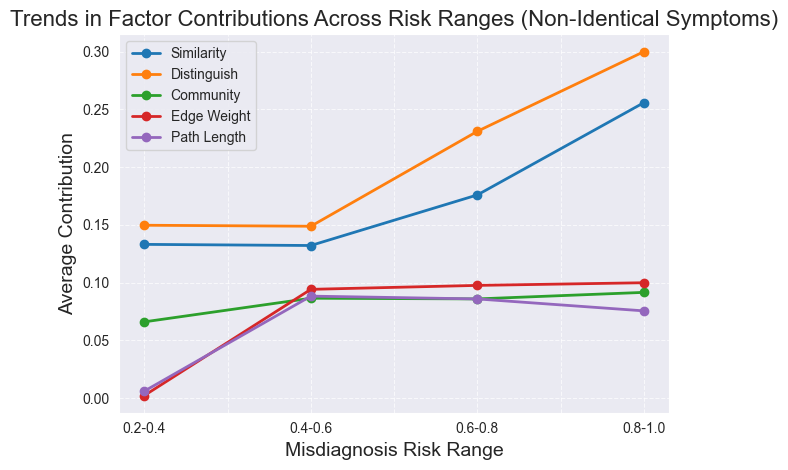

In [30]:
# Now we can visualize. First, I will visualize the top risk factors for misdiagnosis.
def get_similarity(pair_to_get):
    return pair_to_get["misdiagnosis_risk"]

def define_risk_range(misdiagnosis_risk):
    if misdiagnosis_risk >= 0.8:
        return "0.8-1.0"
    elif misdiagnosis_risk >= 0.6:
        return "0.6-0.8"
    elif misdiagnosis_risk >= 0.4:
        return "0.4-0.6"
    elif misdiagnosis_risk >= 0.2:
        return "0.2-0.4"
    else:
        return "0.0-0.2"

non_identical_pairs = []
factor_trends = []

# Now I just get all of the non identical pairs, storing them in another list
for pair in new_sorted_pairs:
    if pair["risk_category"] == "Non_Identical_Symptoms":
        non_identical_pairs.append(pair)

# Looping through the non-identical pairs...
# Need to calcualte the factor contributions
# This is literally just using the calculations I did before
for pair in non_identical_pairs:

    # Similarity contribution
    similarity_contribution = 0.40 * pair["similarity"]

    # Distinguish contribution (all unique / all symptoms)
    dist_contribution = 0.30 * pair["distinguish_factor"]

    # Community contribution
    community_contribution = 0.10 * calculate_community_factor(pair, node_communities)

    # Edge weight contribution
    edge_contribution = 0.10 * min(1, pair["avg_common_weight"] / 10)

    # Path contribution
    # Making sure they aren't infinity
      # Now we handle the path factor
    if pair["avg_path_first_unique"] != float("inf") and pair["avg_path_second_unique"] != float("inf"):
        # We add both to get the average (dividing by 2)
        avg_unique_path = (pair["avg_path_first_unique"] + pair["avg_path_second_unique"]) / 2

        if avg_unique_path != 0:
            # Defined the avg_path network before...
            path_contribution = 0.10 * min(1, avg_path_network / (avg_unique_path))
        else:
            path_contribution = 0
    else:
        path_contribution = 0

    factor_trends.append({
        "Risk Range": define_risk_range(pair["misdiagnosis_risk"]),
        "Similarity": similarity_contribution,
        "Distinguish": dist_contribution,
        "Community": community_contribution,
        "Edge Weight": edge_contribution,
        "Path Length": path_contribution,
    })

# We create the dataframe now to make it easier to plot with seaborn
trends_df = pd.DataFrame(factor_trends)

# Now, we have all of those, but now we calculate the average
avg_trends_df = trends_df.groupby("Risk Range").mean().reset_index()

# https://pandas.pydata.org/docs/reference/api/pandas.melt.html
# This converts it to a format where each row is in an oberservation-variable pair
# This is because the risk range is the id var
# The contributions are the value vars
trends_df_long = avg_trends_df.melt(
    id_vars = ["Risk Range"],
    value_vars = ["Similarity", "Community", "Distinguish", "Edge Weight", "Path Length"],
    var_name = "Factor",
    value_name = "Contribution"
)

# Now we just order the risk ranges.
# Since they are strings, we actually need to order it ourselves.
order_of_risks = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

# Now we can finally plot. Will plot the
plt.figure(figsize=(12, 8))

factor_trends = avg_trends_df.set_index('Risk Range')
factor_trends.plot(marker='o', linewidth=2)

plt.title('Trends in Factor Contributions Across Risk Ranges (Non-Identical Symptoms)', fontsize=16)
plt.xlabel('Misdiagnosis Risk Range', fontsize=14)
plt.ylabel('Average Contribution', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('trends_in_contributions.png', dpi=300, bbox_inches='tight')
plt.tight_layout()



In [31]:
def get_misdiagnosis_rate(pair_to_get):
    return pair_to_get["misdiagnosis_risk"]

sorted_misdiagnosis_pairs = sorted(non_identical_pairs, key=get_misdiagnosis_rate, reverse=True)

limited_misdiagnosis_pairs = sorted_misdiagnosis_pairs[:10]
index = 1
for pair in limited_misdiagnosis_pairs:
    print("-------------------------------------------------------")
    print(f"RANK {index}")
    print(f"First disease: {pair["first_disease"]}")
    print(f"Second disease: {pair["second_disease"]}")
    print(f"Jaccard Similarity: {pair["similarity"]}")
    print(f"Common symptoms: {pair["common_symptoms"]}")
    print(f"Unique 1: {pair["first_unique_symptoms"]}")
    print(f"Unique 2: {pair["second_unique_symptoms"]}")
    print(f"Number of communities overlap: {pair["num_communities_overlap"]}")
    print(f"Communities involved: {pair["involved_communities"]}")
    print(f"Average common weight: {pair["avg_common_weight"]}")
    print(f"Misdiagnosis rate: {pair["misdiagnosis_risk"]}")
    index += 1



-------------------------------------------------------
RANK 1
First disease: Pulmonary Nodular Disease
Second disease: Pediatric Langerhans Cell Histiocytosis
Jaccard Similarity: 0.75
Common symptoms: ['loss of appetite', 'night sweats', 'weight loss', 'fatigue', 'fever', 'cough']
Unique 1: ['hemoptysis']
Unique 2: ['difficulty breathing']
Number of communities overlap: 2
Communities involved: {1, 2}
Average common weight: 98.6
Misdiagnosis rate: 0.9
-------------------------------------------------------
RANK 2
First disease: Tapeworm Infection
Second disease: Taeniasis
Jaccard Similarity: 0.75
Common symptoms: ['abdominal pain', 'fatigue', 'bloating', 'diarrhea', 'itching', 'nausea']
Unique 1: ['feces']
Unique 2: ['white segments in stools']
Number of communities overlap: 2
Communities involved: {1, 6}
Average common weight: 109.8
Misdiagnosis rate: 0.8875000000000001
-------------------------------------------------------
RANK 3
First disease: Pseudo-intestinal Obstruction
Second d